# 04 · Multiclass: more than two answers
NumPy for the model · matplotlib for graphs · Runs on Google Colab

1. The problem: one output can't hold 3 classes
2. One output neuron per class
3. Softmax: scores ➜ probabilities
4. Cross-entropy: the loss for probabilities
5. Train: 3 clusters (no hidden layer) ➜ 3 spirals (hidden layer)
6. Experiments

## Data: 3 clusters of points (classes 0, 1, 2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
np.set_printoptions(precision=4, suppress=True)
COLORS = ["#e41a1c", "#377eb8", "#4daf4a", "#c871c3"]
SHADES = ["#f8d0d0", "#d0e0f4", "#d6efd5", "#d9d9d9"]               # class 0, 1, 2, ambiguous

def make_clusters(n=60):
    centers = np.array([[0, 0], [3, 0], [1.5, 2.6]])
    X = np.vstack([c + rng.normal(0, 0.6, (n, 2)) for c in centers])
    y = np.repeat([0, 1, 2], n)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

def split(X, y, test_ratio=0.2):
    n_test = int(len(X) * test_ratio)
    return X[n_test:], X[:n_test], y[n_test:], y[:n_test]

def add_x0(X):
    return np.hstack([-np.ones((len(X), 1)), X])                  # x0 = -1, so w0 is the threshold

X, y = make_clusters()
Xtr, Xte, ytr, yte = split(X, y)
Xtr0, Xte0 = add_x0(Xtr), add_x0(Xte)
print("Shape:", X.shape, "| per class:", np.bincount(y), f"| train {len(ytr)}, test {len(yte)}")

Shape: (180, 2) | per class: [60 60 60] | train 144, test 36


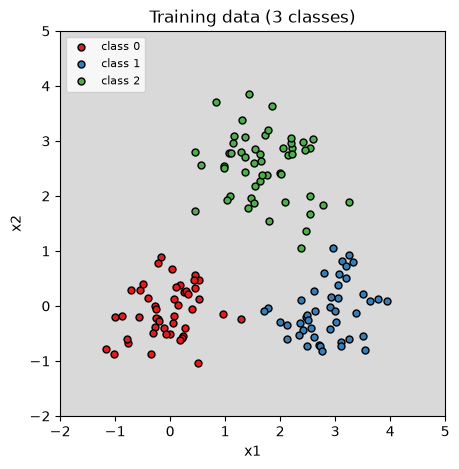

In [2]:
def plot_classes(ax, predict, X, y, title, lims=(-2, 5)):
    # predict: points (n×2) -> class 0/1/2, or 3 for "ambiguous"
    g = np.linspace(*lims, 250)
    G1, G2 = np.meshgrid(g, g)
    Z = predict(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    ax.contourf(G1, G2, Z, levels=[-0.5, 0.5, 1.5, 2.5, 3.5], colors=SHADES)
    for k in range(3):
        ax.scatter(X[y == k, 0], X[y == k, 1], c=COLORS[k], edgecolors="k", s=25, label=f"class {k}")
    ax.set(xlim=lims, ylim=lims, xlabel="x1", ylabel="x2", title=title, aspect="equal")
    ax.legend(loc="upper left", fontsize=8)

fig, ax = plt.subplots(figsize=(5, 5))
plot_classes(ax, lambda P: np.full(len(P), 3), Xtr, ytr, "Training data (3 classes)")
plt.show()

---
# Part 1: the problem — one sigmoid output for 3 classes
Code the classes as targets 0, 0.5, 1 and pick the nearest one.

Test accuracy: 75.0%


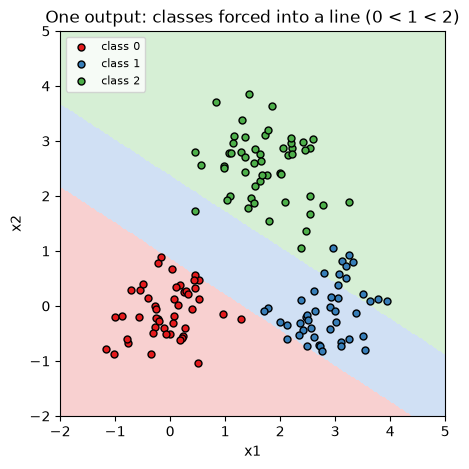

In [3]:
def sigmoid(s):
    return 1 / (1 + np.exp(-s))

def d_sigmoid(s):
    return sigmoid(s) * (1 - sigmoid(s))

w = rng.uniform(-1, 1, 3)
for epoch in range(200):
    for x, target in zip(Xtr0, ytr / 2):                         # targets 0, 0.5, 1
        s = x @ w
        w = w + 0.1 * (target - sigmoid(s)) * d_sigmoid(s) * x    # delta rule

one_output = lambda P: np.round(sigmoid(add_x0(P) @ w) * 2).astype(int)
print(f"Test accuracy: {100 * (one_output(Xte) == yte).mean():.1f}%")
fig, ax = plt.subplots(figsize=(5, 5))
plot_classes(ax, one_output, Xtr, ytr, "One output: classes forced into a line (0 < 1 < 2)")
plt.show()

One number puts class 1 **between** 0 and 2, so the regions are parallel bands. The data doesn't have that order.

---
# Part 2: one output neuron per class
One-hot targets: class 0 ➜ `[1, 0, 0]`, class 1 ➜ `[0, 1, 0]`, class 2 ➜ `[0, 0, 1]`. Each output is a sigmoid trained with the delta rule; pick the largest (**argmax**).

In [4]:
Ytr = np.eye(3)[ytr]                                              # one-hot targets
print("First 3 targets:", ytr[:3], "->\n", Ytr[:3])

W_sig = rng.uniform(-1, 1, (3, 3))                                # column k = output neuron k: [w0, w1, w2]
for epoch in range(200):
    for x, t in zip(Xtr0, Ytr):
        s = x @ W_sig
        W_sig = W_sig + 0.1 * np.outer(x, (t - sigmoid(s)) * d_sigmoid(s))

out = sigmoid(Xte0[:5] @ W_sig)
for o, t in zip(out, yte[:5]):
    print(f"outputs {o} | sum {o.sum():.2f} | argmax {o.argmax()} | true {t}")

First 3 targets: [0 2 0] ->
 [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]]
outputs [0.0009 0.8149 0.0982] | sum 0.91 | argmax 1 | true 1
outputs [0.0034 0.1966 0.3221] | sum 0.52 | argmax 2 | true 1
outputs [0.0013 0.0001 0.9988] | sum 1.00 | argmax 2 | true 2
outputs [0.0008 0.9983 0.0021] | sum 1.00 | argmax 1 | true 1
outputs [0.8935 0.066  0.0051] | sum 0.96 | argmax 0 | true 0


Test accuracy (argmax): 97.2%
Share of the plane where 0 or 2+ outputs say 'yes': 24.0%


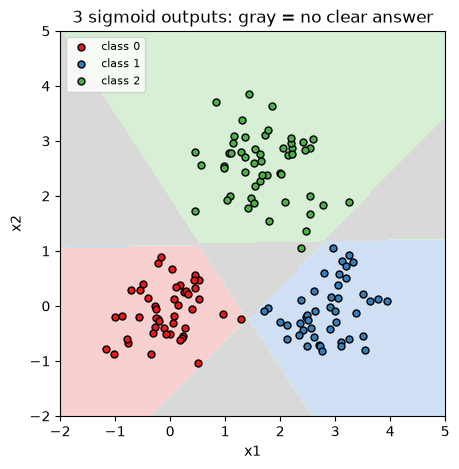

In [5]:
def ambiguous_or_argmax(P):
    o = sigmoid(add_x0(P) @ W_sig)
    above = (o >= 0.5).sum(axis=1)
    return np.where(above == 1, o.argmax(axis=1), 3)              # 3 = none or several above 0.5

G = rng.uniform(-2, 5, (5000, 2))
print(f"Test accuracy (argmax): {100 * ((sigmoid(Xte0 @ W_sig)).argmax(axis=1) == yte).mean():.1f}%")
print(f"Share of the plane where 0 or 2+ outputs say 'yes': {100 * (ambiguous_or_argmax(G) == 3).mean():.1f}%")
fig, ax = plt.subplots(figsize=(5, 5))
plot_classes(ax, ambiguous_or_argmax, Xtr, ytr, "3 sigmoid outputs: gray = no clear answer")
plt.show()

The outputs don't add up to 1, so they are not probabilities, and some regions have no clear answer.

---
# Part 3: softmax — scores ➜ probabilities

$$p_k = \frac{e^{s_k}}{\sum_j e^{s_j}}$$

In [6]:
def softmax(s):
    e = np.exp(s - s.max())                                       # subtracting the max avoids overflow, same result
    return e / e.sum()

scores = np.array([2.0, 1.0, 0.1])
e = np.exp(scores)
print("scores        :", scores)
print("e^scores      :", e)
print("sum           :", round(e.sum(), 4))
print("probabilities :", e / e.sum(), f"| sum = {(e / e.sum()).sum():.4f}")
print("softmax()     :", softmax(scores))

print("\nNudge score 0 by +0.5: all probabilities change, the sum stays 1")
p_new = softmax(scores + np.array([0.5, 0, 0]))
print("probabilities :", p_new, f"| sum = {p_new.sum():.4f}")

scores        : [2.  1.  0.1]
e^scores      : [7.3891 2.7183 1.1052]
sum           : 11.2125
probabilities : [0.659  0.2424 0.0986] | sum = 1.0000
softmax()     : [0.659  0.2424 0.0986]

Nudge score 0 by +0.5: all probabilities change, the sum stays 1
probabilities : [0.7611 0.1698 0.069 ] | sum = 1.0000


---
# Part 4: cross-entropy — the loss for probabilities

$$\text{loss} = -\log(p_{\text{correct class}})$$

In [7]:
for p in [0.99, 0.9, 0.5, 0.1, 0.01]:
    print(f"probability of the correct class {p:4.2f} -> loss = -log({p}) = {-np.log(p):.3f}")

probability of the correct class 0.99 -> loss = -log(0.99) = 0.010
probability of the correct class 0.90 -> loss = -log(0.9) = 0.105
probability of the correct class 0.50 -> loss = -log(0.5) = 0.693
probability of the correct class 0.10 -> loss = -log(0.1) = 2.303
probability of the correct class 0.01 -> loss = -log(0.01) = 4.605


Confident and right ➜ tiny loss. Confident and wrong ➜ huge loss.

**Slope of the loss for each score** (checked by nudging): it is simply $p_k - y_k$, so the delta rule becomes $\delta = y - p$, just like before.

In [8]:
target = np.array([0, 1, 0])                                      # correct class = 1
loss = lambda s: -np.log(softmax(s)[1])
p = softmax(scores)
for k in range(3):
    nudge = np.zeros(3)
    nudge[k] = 0.001
    by_nudging = (loss(scores + nudge) - loss(scores)) / 0.001
    print(f"score {k}: slope by nudging = {by_nudging:+.4f} | p - y = {p[k]:.4f} - {target[k]} = {p[k] - target[k]:+.4f}")

score 0: slope by nudging = +0.6591 | p - y = 0.6590 - 0 = +0.6590
score 1: slope by nudging = -0.7575 | p - y = 0.2424 - 1 = -0.7576
score 2: slope by nudging = +0.0986 | p - y = 0.0986 - 0 = +0.0986


---
# Part 5a: softmax output on the 3 clusters (no hidden layer)

| Function | What it does |
|---|---|
| `forward_pass(x, W)` | $p = \text{softmax}(x \cdot W)$ |
| `compute_error(y, p)` | $y - p$ (one-hot target minus probabilities) |
| `backward_pass(W, x, error, lr)` | $W + \eta \cdot x \otimes \text{error}$ |

In [9]:
def forward_pass(x, W):
    return softmax(x @ W)

def compute_error(y, p):
    return y - p

def backward_pass(W, x, error, lr):
    return W + lr * np.outer(x, error)

def cross_entropy(Y, P):
    return -np.mean(np.log(np.sum(Y * P, axis=1) + 1e-12))


def train(X, Y, W, lr, epochs):
    for epoch in range(1, epochs + 1):
        probs = []
        for x, t in zip(X, Y):
            p = forward_pass(x, W)
            error = compute_error(t, p)
            W = backward_pass(W, x, error, lr)
            probs.append(p)
        if epoch == 1 or epoch % (epochs // 5) == 0:
            acc = 100 * (np.argmax(probs, axis=1) == Y.argmax(axis=1)).mean()
            print(f"Epoch {epoch:3d} | loss {cross_entropy(Y, np.array(probs)):.4f} | train accuracy {acc:5.1f}%")
    return W

Epoch   1 | loss 0.2955 | train accuracy  91.0%
Epoch  10 | loss 0.0380 | train accuracy  99.3%
Epoch  20 | loss 0.0264 | train accuracy 100.0%
Epoch  30 | loss 0.0216 | train accuracy 100.0%
Epoch  40 | loss 0.0189 | train accuracy 100.0%
Epoch  50 | loss 0.0170 | train accuracy 100.0%

Test accuracy: 97.2%

probabilities [0.0013 0.9658 0.0329] | sum 1.00 | predicted 1 | true 1
probabilities [0.019  0.3075 0.6735] | sum 1.00 | predicted 2 | true 1
probabilities [0. 0. 1.] | sum 1.00 | predicted 2 | true 2
probabilities [0. 1. 0.] | sum 1.00 | predicted 1 | true 1
probabilities [0.9815 0.0166 0.002 ] | sum 1.00 | predicted 0 | true 0


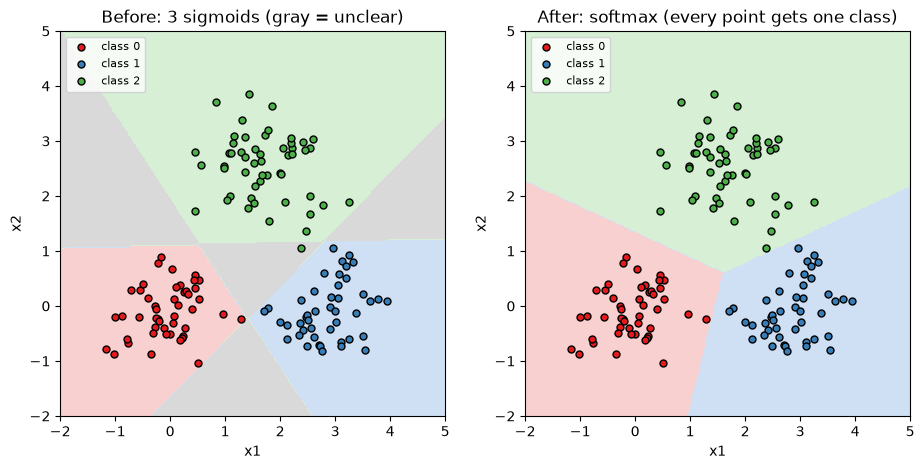

In [10]:
W_soft = train(Xtr0, Ytr, rng.uniform(-1, 1, (3, 3)), lr=0.1, epochs=50)

predict_soft = lambda P: np.array([forward_pass(x, W_soft).argmax() for x in add_x0(P)])
print(f"\nTest accuracy: {100 * (predict_soft(Xte) == yte).mean():.1f}%\n")
for x, t in zip(Xte0[:5], yte[:5]):
    p = forward_pass(x, W_soft)
    print(f"probabilities {p} | sum {p.sum():.2f} | predicted {p.argmax()} | true {t}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
plot_classes(axes[0], ambiguous_or_argmax, Xtr, ytr, "Before: 3 sigmoids (gray = unclear)")
plot_classes(axes[1], predict_soft, Xtr, ytr, "After: softmax (every point gets one class)")
plt.show()

---
# Part 5b: 3 spirals — needs a hidden layer (the multiclass XOR)
Network 2 ➜ 20 (tanh) ➜ 3 (softmax).

In [11]:
def make_spirals(n=80, noise=0.2):
    X, y = [], []
    for k in range(3):
        r = np.linspace(0.1, 1, n)
        t = np.linspace(k * 4, (k + 1) * 4, n) + rng.normal(0, noise, n)
        X.append(np.c_[r * np.sin(t), r * np.cos(t)])
        y += [k] * n
    X, y = np.vstack(X), np.array(y)
    idx = rng.permutation(len(X))
    return X[idx], y[idx]

Xs, ys = make_spirals()
Xs_tr, Xs_te, ys_tr, ys_te = split(Xs, ys)
Xs_tr0, Xs_te0 = add_x0(Xs_tr), add_x0(Xs_te)
Ys_tr = np.eye(3)[ys_tr]
SP = (-1.2, 1.2)

W_lin = train(Xs_tr0, Ys_tr, rng.uniform(-1, 1, (3, 3)), lr=0.1, epochs=50)
print(f"No hidden layer, test accuracy: {100 * (np.argmax(Xs_te0 @ W_lin, axis=1) == ys_te).mean():.1f}%")

Epoch   1 | loss 1.0059 | train accuracy  49.0%
Epoch  10 | loss 0.7678 | train accuracy  54.7%
Epoch  20 | loss 0.7680 | train accuracy  54.2%
Epoch  30 | loss 0.7681 | train accuracy  54.2%
Epoch  40 | loss 0.7681 | train accuracy  54.2%
Epoch  50 | loss 0.7681 | train accuracy  54.2%
No hidden layer, test accuracy: 47.9%


In [12]:
def new_net(hidden):
    return {"W1": rng.uniform(-1, 1, (3, hidden)), "W2": rng.uniform(-1, 1, (hidden + 1, 3))}

def mlp_forward_pass(x, net):
    s1 = x @ net["W1"]
    h = np.r_[-1, np.tanh(s1)]                                    # h0 = -1 for the output thresholds
    return softmax(h @ net["W2"]), (s1, h)

def mlp_backward_pass(net, x, error, cache, lr):
    s1, h = cache
    delta_out = error                                             # softmax + cross-entropy: y - p
    delta_hidden = (net["W2"][1:] @ delta_out) * (1 - np.tanh(s1) ** 2)
    dW2 = -np.outer(h, delta_out)
    dW1 = -np.outer(x, delta_hidden)
    return {"W1": net["W1"] - lr * dW1, "W2": net["W2"] - lr * dW2}

def mlp_predict(P, net):
    H = np.hstack([-np.ones((len(P), 1)), np.tanh(add_x0(P) @ net["W1"])])
    return np.argmax(H @ net["W2"], axis=1)


def mlp_train(X, Y, net, lr, epochs, show=True):
    losses, snapshots = [], {}
    for epoch in range(1, epochs + 1):
        probs = []
        for x, t in zip(X, Y):
            p, cache = mlp_forward_pass(x, net)
            error = compute_error(t, p)
            net = mlp_backward_pass(net, x, error, cache, lr)
            probs.append(p)
        losses.append(cross_entropy(Y, np.array(probs)))
        snapshots[epoch] = net
        if show and (epoch == 1 or epoch % (epochs // 6) == 0):
            acc = 100 * (np.argmax(probs, axis=1) == Y.argmax(axis=1)).mean()
            print(f"Epoch {epoch:3d} | loss {losses[-1]:.4f} | train accuracy {acc:5.1f}%")
    return net, losses, snapshots

In [13]:
net, losses, snapshots = mlp_train(Xs_tr0, Ys_tr, new_net(20), lr=0.05, epochs=300)
print(f"\nTest accuracy: {100 * (mlp_predict(Xs_te, net) == ys_te).mean():.1f}%")

Epoch   1 | loss 0.9307 | train accuracy  52.1%
Epoch  50 | loss 0.0844 | train accuracy  97.9%
Epoch 100 | loss 0.0346 | train accuracy  99.5%
Epoch 150 | loss 0.0177 | train accuracy 100.0%
Epoch 200 | loss 0.0111 | train accuracy 100.0%
Epoch 250 | loss 0.0078 | train accuracy 100.0%
Epoch 300 | loss 0.0060 | train accuracy 100.0%

Test accuracy: 100.0%


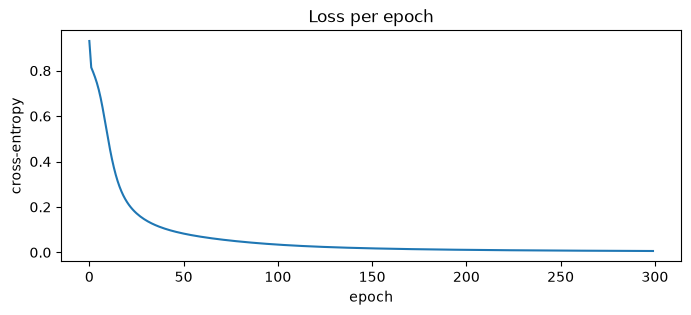

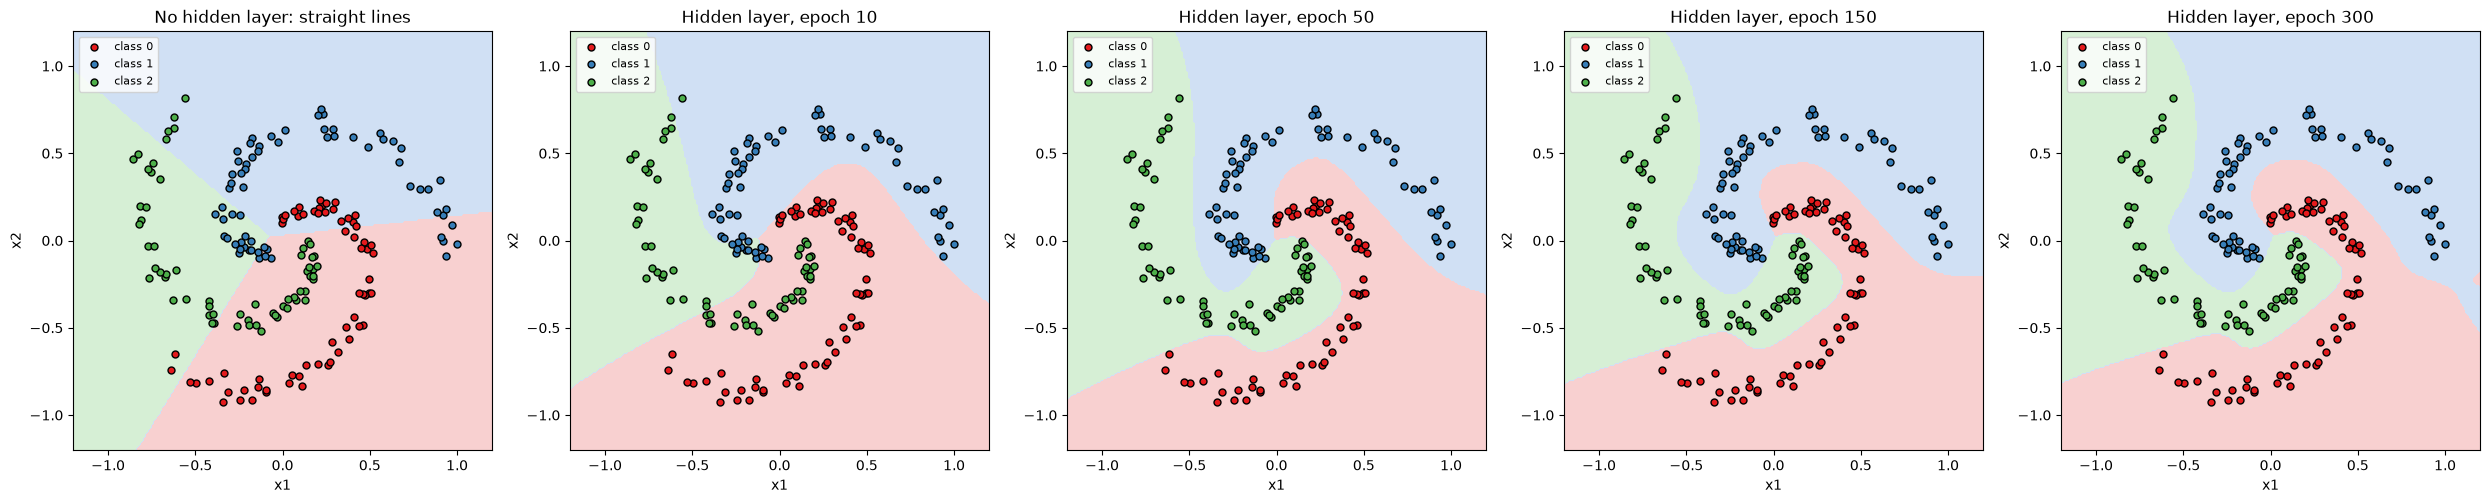

In [14]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses)
ax.set(xlabel="epoch", ylabel="cross-entropy", title="Loss per epoch")
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
plot_classes(axes[0], lambda P: np.argmax(add_x0(P) @ W_lin, axis=1), Xs_tr, ys_tr, "No hidden layer: straight lines", SP)
for ax, e in zip(axes[1:], [10, 50, 150, 300]):
    plot_classes(ax, lambda P: mlp_predict(P, snapshots[e]), Xs_tr, ys_tr, f"Hidden layer, epoch {e}", SP)
plt.tight_layout()
plt.show()

---
# Part 6: Experiments (spirals)
## 1. Hidden layer size (η = 0.05, 300 epochs)

hidden  2: test accuracy  79.2%
hidden  5: test accuracy  97.9%
hidden 10: test accuracy 100.0%
hidden 20: test accuracy  97.9%
hidden 50: test accuracy 100.0%


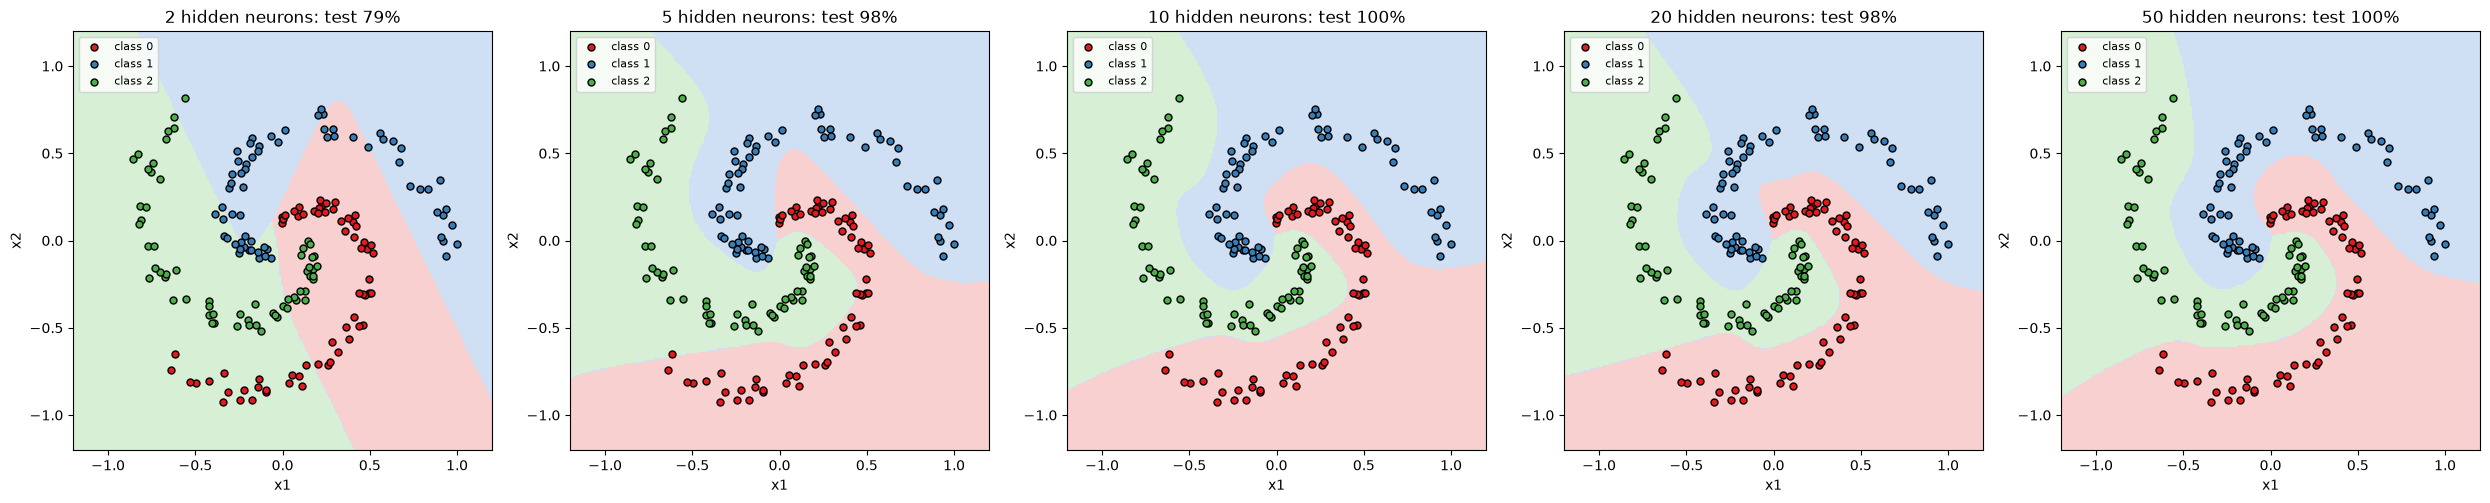

In [15]:
sizes = [2, 5, 10, 20, 50]
fig, axes = plt.subplots(1, len(sizes), figsize=(25, 5))
for ax, hidden in zip(axes, sizes):
    trained, _, _ = mlp_train(Xs_tr0, Ys_tr, new_net(hidden), 0.05, 300, show=False)
    acc = 100 * (mlp_predict(Xs_te, trained) == ys_te).mean()
    print(f"hidden {hidden:>2}: test accuracy {acc:5.1f}%")
    plot_classes(ax, lambda P: mlp_predict(P, trained), Xs_tr, ys_tr, f"{hidden} hidden neurons: test {acc:.0f}%", SP)
plt.tight_layout()
plt.show()

## 2. Learning rate (20 hidden, same start, 300 epochs)

η = 0.001: test accuracy  50.0%
η = 0.01 : test accuracy  95.8%
η = 0.05 : test accuracy  97.9%
η = 0.5  : test accuracy  97.9%
η = 2    : test accuracy  31.2%


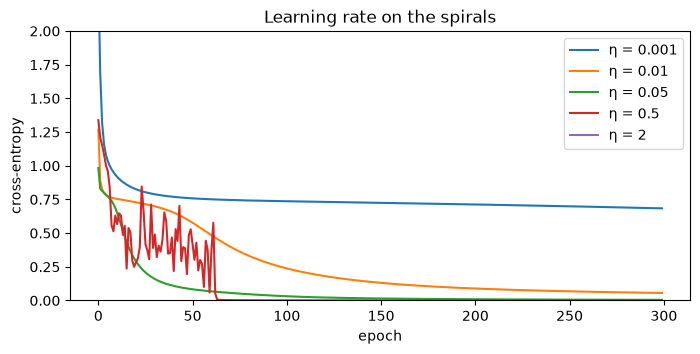

In [16]:
start = new_net(20)
fig, ax = plt.subplots(figsize=(8, 3.5))
for lr in [0.001, 0.01, 0.05, 0.5, 2]:
    trained, loss_run, _ = mlp_train(Xs_tr0, Ys_tr, start, lr, 300, show=False)
    print(f"η = {lr:<5}: test accuracy {100 * (mlp_predict(Xs_te, trained) == ys_te).mean():5.1f}%")
    ax.plot(loss_run, label=f"η = {lr}")
ax.set(xlabel="epoch", ylabel="cross-entropy", ylim=(0, 2), title="Learning rate on the spirals")
ax.legend()
plt.show()

## 3. Cross-entropy vs MSE (same network and start)
MSE + softmax: error passed back is $(y - p)$ times the slope of softmax, which is small when the network is confidently wrong.

cross-entropy: train accuracy after 50 epochs 99.0%, after 300 epochs 100.0%
          MSE: train accuracy after 50 epochs 94.8%, after 300 epochs 100.0%


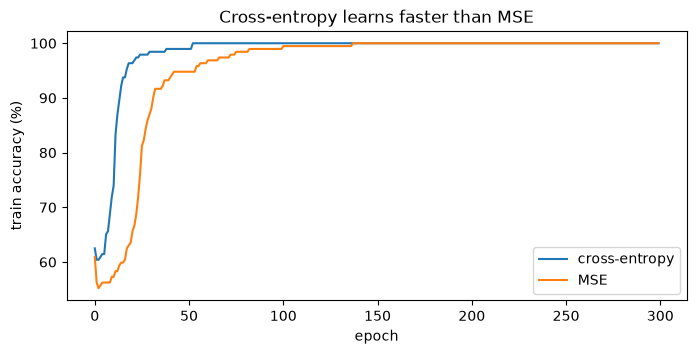

In [17]:
def mse_backward_pass(net, x, error, cache, lr):
    p = softmax(cache[1] @ net["W2"])
    jacobian = np.diag(p) - np.outer(p, p)                        # slope of each p_k for each score
    return mlp_backward_pass(net, x, jacobian @ error, cache, lr)

def train_with(backward, net, epochs=300, lr=0.05):
    accs = []
    for epoch in range(epochs):
        for x, t in zip(Xs_tr0, Ys_tr):
            p, cache = mlp_forward_pass(x, net)
            net = backward(net, x, compute_error(t, p), cache, lr)
        accs.append(100 * (mlp_predict(Xs_tr, net) == ys_tr).mean())
    return accs

start = new_net(20)
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, backward in [("cross-entropy", mlp_backward_pass), ("MSE", mse_backward_pass)]:
    accs = train_with(backward, start)
    print(f"{name:>13}: train accuracy after 50 epochs {accs[49]:.1f}%, after 300 epochs {accs[-1]:.1f}%")
    ax.plot(accs, label=name)
ax.set(xlabel="epoch", ylabel="train accuracy (%)", title="Cross-entropy learns faster than MSE")
ax.legend()
plt.show()

Next notebook: the same functions on real multiclass datasets (Iris, Wine, handwritten digits).

In [18]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [19]:
iris = load_iris()

In [20]:
x, y = iris.data, iris.target

In [21]:
xs_tr, xs_te, ys_tr, ys_te = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
mean, std = xs_tr.mean(axis=0), xs_tr.std(axis=0)

In [23]:
xs_tr0 = (xs_tr-mean)/std
xs_te0 = (xs_te-mean)/std

In [24]:
num_classes = 3
ys_tr = np.eye(num_classes)[ys_tr]

In [25]:
def relu(z):
    return np.maximum(0, z)

In [26]:
def softmax(z):
    e = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

In [27]:
def compute_error(t, p):
    return t - p

In [28]:
def new_net(n_hidden=20, n_in=4, n_out=3, seed=42):
    rng = np.random.default_rng(seed)
    return {
        "W1": rng.normal(0, np.sqrt(2 / n_in), (n_in, n_hidden)),
        "b1": np.zeros(n_hidden),
        "W2": rng.normal(0, np.sqrt(2 / n_hidden), (n_hidden, n_out)),
        "b2": np.zeros(n_out),
    }

In [29]:
def mlp_forward_pass(x, net):
    z1 = x @ net["W1"] + net["b1"]
    h1 = relu(z1)
    z2 = h1 @ net["W2"] + net["b2"]
    p = softmax(z2)
    cache = (z1, h1)
    return p, cache

In [30]:
def mlp_backward_pass(net, x, error, cache, lr):
    z1, h1 = cache
    net = {k: v.copy() for k, v in net.items()}
    
    # Output layer gradients (error = t - p)
    dW2 = np.outer(h1, error)
    db2 = error
    
    # Hidden layer gradients
    dh1 = net["W2"] @ error
    dz1 = dh1 * (z1 > 0)
    dW1 = np.outer(x, dz1)
    db1 = dz1
    
    # Gradient ascent step because error is (t - p) instead of (p - t)
    net["W2"] += lr * dW2
    net["b2"] += lr * db2
    net["W1"] += lr * dW1
    net["b1"] += lr * db1
    return net

In [31]:
def mlp_predict(X, net):
    h1 = relu(X @ net["W1"] + net["b1"])
    probs = softmax(h1 @ net["W2"] + net["b2"])
    return np.argmax(probs, axis=1)

Final Train Accuracy: 98.3%
Final Test Accuracy:  96.7%


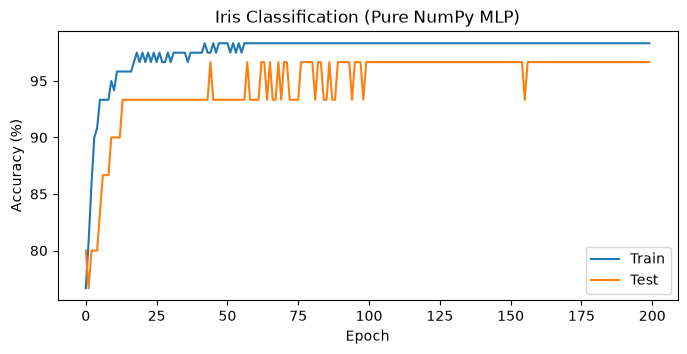

In [32]:
net = new_net(n_hidden=20, n_in=4, n_out=3)
epochs = 200
lr = 0.01

train_accs, test_accs = [], []

for epoch in range(epochs):
    # Shuffle each epoch for better SGD convergence
    idx = np.random.permutation(len(xs_tr0))
    for i in idx:
        p, cache = mlp_forward_pass(xs_tr0[i], net)
        err = compute_error(ys_tr[i], p)
        net = mlp_backward_pass(net, xs_tr0[i], err, cache, lr)
        
    train_accs.append(100 * (mlp_predict(xs_tr0, net) == np.argmax(ys_tr, axis=1)).mean())
    test_accs.append(100 * (mlp_predict(xs_te0, net) == (np.argmax(ys_te, axis=1) if ys_te.ndim == 2 else ys_te)).mean())

print(f"Final Train Accuracy: {train_accs[-1]:.1f}%")
print(f"Final Test Accuracy:  {test_accs[-1]:.1f}%")

plt.figure(figsize=(8, 3.5))
plt.plot(train_accs, label="Train")
plt.plot(test_accs, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Iris Classification (Pure NumPy MLP)")
plt.legend()
plt.show()